In [10]:
import pandas as pd
import numpy as np
df = pd.read_csv("delhi_metro_updated.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  object 
 9   Remarks             123743 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [11]:
df.isnull().sum()

TripID                    0
Date                      0
From_Station              0
To_Station                0
Distance_km               0
Fare                      0
Cost_per_passenger        0
Passengers             1500
Ticket_Type            1500
Remarks               26257
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,150000.000000,150000.000000,150000.000000,150000.000000,148500.000000
mean,75000.500000,5.490446,105.116503,62.474807,20.003522
std,43301.414527,4.980333,54.879494,33.207161,4.468134
min,1.000000,0.500000,10.000000,5.000000,4.000000
25%,37500.750000,1.940000,57.570000,33.687500,17.000000
50%,75000.500000,3.960000,105.170000,62.520000,20.000000
75%,112500.250000,7.420000,152.572500,91.190000,23.000000
max,150000.000000,63.030000,200.000000,120.000000,41.000000


In [15]:
df.describe(include='object')

,Date,From_Station,To_Station,Ticket_Type,Remarks
count,150000,150000,150000,148500,123743
unique,1095,663,24,4,5
top,10-08-2024,Rajiv Chowk,Hauz Khas,Tourist Card,off-peak
freq,183,15593,6372,59193,24859


In [16]:

df["To_Station"].value_counts().head(10)

To_Station
Hauz Khas               6372
Kirti Nagar             6371
Janakpuri West          6340
Noida City Centre       6338
Old Delhi               6313
Netaji Subhash Place    6312
Dilshad Garden          6306
Kashmere Gate           6295
Pragati Maidan          6282
Kalkaji Mandir          6273
Name: count, dtype: int64

In [17]:
df["Ticket_Type"].value_counts()

Ticket_Type
Tourist Card    59193
Single          37341
Smart Card      37244
Return          14722
Name: count, dtype: int64

In [18]:
df["Remarks"].value_counts()

Remarks
off-peak       24859
festival       24812
maintenance    24771
weekend        24710
peak           24591
Name: count, dtype: int64

In [19]:


df["From_Station"].value_counts().head(10)

From_Station
Rajiv Chowk            15593
Noida City Centre      12049
New Delhi               8173
Mandi House             8044
Dilshad Garden          4461
Chandni Chowk           4420
Kalkaji Mandir          4417
Central Secretariat     4413
Janakpuri West          4412
Laxmi Nagar             4408
Name: count, dtype: int64

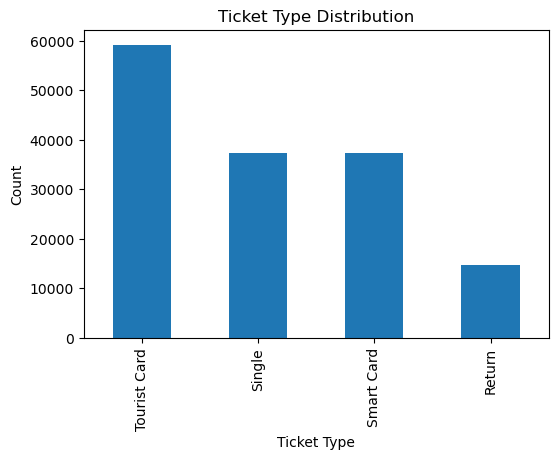

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
ticket_counts = df["Ticket_Type"].value_counts()

plt.figure(figsize=(6,4))
ticket_counts.plot(kind="bar")

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")

plt.show()

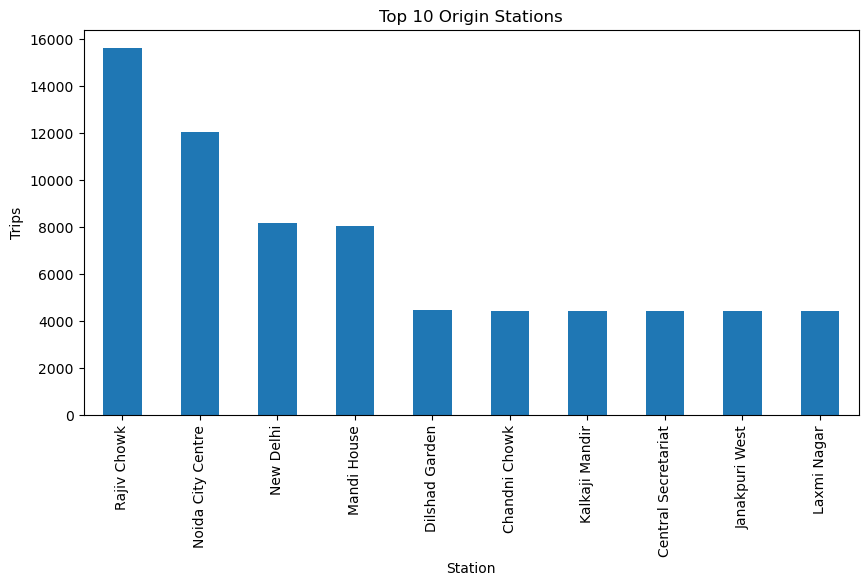

In [22]:
plt.figure(figsize=(10,5))

df["From_Station"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Origin Stations")
plt.xlabel("Station")
plt.ylabel("Trips")

plt.show()

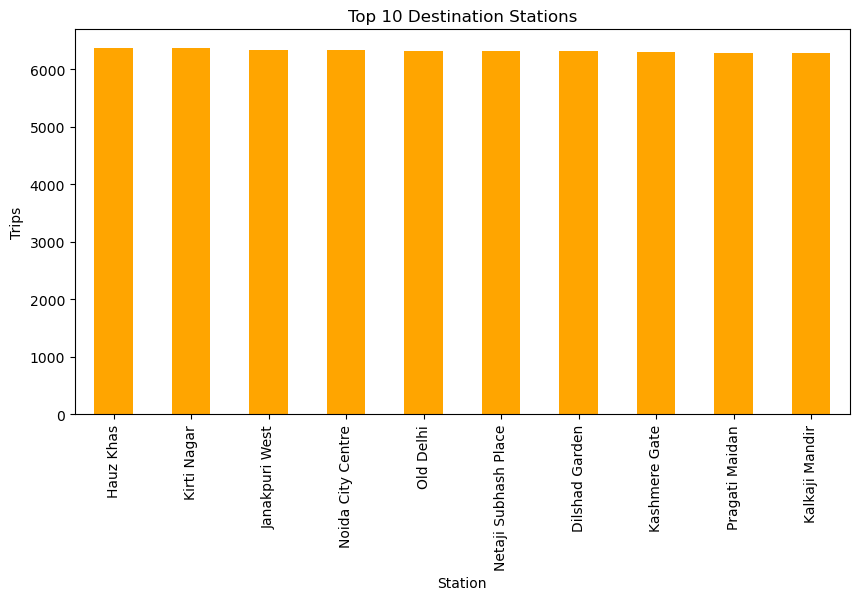

In [23]:
plt.figure(figsize=(10,5))

df["To_Station"].value_counts().head(10).plot(kind="bar", color="orange")

plt.title("Top 10 Destination Stations")
plt.xlabel("Station")
plt.ylabel("Trips")

plt.show()

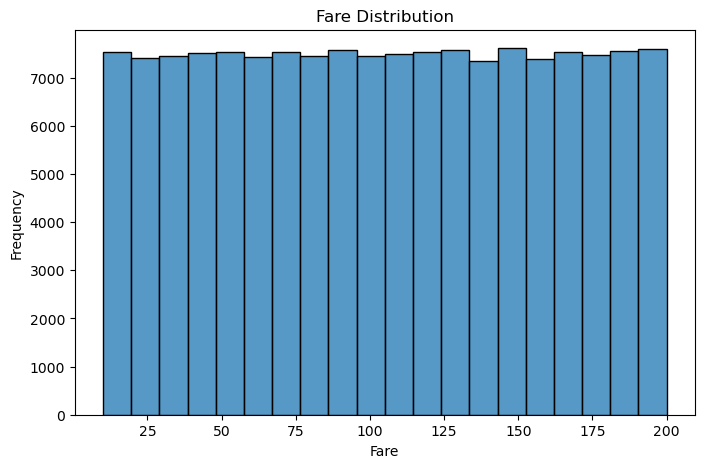

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

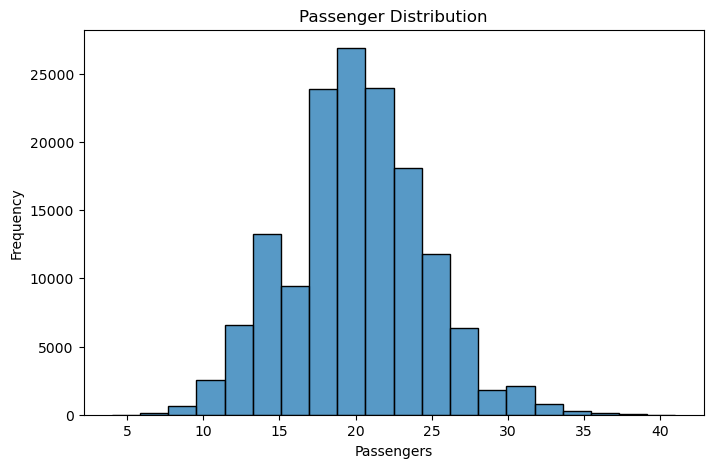

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Passengers"], bins=20)

plt.title("Passenger Distribution")
plt.xlabel("Passengers")
plt.ylabel("Frequency")

plt.show()

In [28]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   TripID              150000 non-null  int64         
 1   Date                150000 non-null  datetime64[ns]
 2   From_Station        150000 non-null  object        
 3   To_Station          150000 non-null  object        
 4   Distance_km         150000 non-null  float64       
 5   Fare                150000 non-null  float64       
 6   Cost_per_passenger  150000 non-null  float64       
 7   Passengers          148500 non-null  float64       
 8   Ticket_Type         148500 non-null  object        
 9   Remarks             123743 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 11.4+ MB


In [30]:
df["Passengers"] = df["Passengers"].fillna(df["Passengers"].median())

In [31]:
df["Ticket_Type"] = df["Ticket_Type"].fillna(df["Ticket_Type"].mode()[0])

In [32]:
df["Remarks"] = df["Remarks"].fillna("Unknown")

In [33]:
df.isnull().sum()

TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64

In [34]:
df.to_csv("delhi_metro_cleaned.csv", index=False)

In [35]:
df= pd.read_csv("Delhi-Metro-Network.csv")

In [36]:
df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,06-04-2008,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,31-10-2018,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,14-11-2013,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,25-12-2017,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,30-12-2005,Elevated,28.619320,77.033260


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Station ID                285 non-null    int64  
 1   Station Name              285 non-null    object 
 2   Distance from Start (km)  285 non-null    float64
 3   Line                      285 non-null    object 
 4   Opening Date              285 non-null    object 
 5   Station Layout            285 non-null    object 
 6   Latitude                  285 non-null    float64
 7   Longitude                 285 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 17.9+ KB


In [39]:
df.isnull().sum()

Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe()

,Station ID,Distance from Start (km),Latitude,Longitude
count,285.000000,285.000000,285.000000,285.000000
mean,143.000000,19.218947,28.595428,77.029315
std,82.416625,14.002862,0.091316,2.875400
min,1.000000,0.000000,27.920862,28.698807
25%,72.000000,7.300000,28.545828,77.107130
50%,143.000000,17.400000,28.613453,77.207220
75%,214.000000,28.800000,28.666360,77.281165
max,285.000000,52.700000,28.878965,77.554479


In [42]:
df["Opening Date"] = pd.to_datetime(df["Opening Date"], dayfirst=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Station ID                285 non-null    int64         
 1   Station Name              285 non-null    object        
 2   Distance from Start (km)  285 non-null    float64       
 3   Line                      285 non-null    object        
 4   Opening Date              285 non-null    datetime64[ns]
 5   Station Layout            285 non-null    object        
 6   Latitude                  285 non-null    float64       
 7   Longitude                 285 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 17.9+ KB


In [44]:
df[df["Longitude"] == df["Longitude"].min()]

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
176,177,Shyam park,4.5,Red line,2019-08-03,Elevated,28.698807,28.698807


In [45]:
df.to_csv("Delhi_Metro_Network_Cleaned.csv", index=False)

In [46]:
df = pd.read_json("schedules.json")

In [47]:
df.head()

,arrival,day,train_name,station_name,station_code,id,train_number,departure
0,None,1.0,Falaknuma Lingampalli MMTS,KACHEGUDA FALAKNUMA,FM,302214,47154,07:55:00
1,None,1.0,Thrissur Guruvayur Passenger,THRISUR,TCR,281458,56044,18:55:00
2,None,1.0,Porbandar Muzaffarpur Express,PORBANDAR,PBR,309335,19269,15:05:00
3,None,1.0,RAIPUR ITWARI PASS,RAIPUR JN,R,283774,58205,13:30:00
4,None,1.0,Gomoh-Asansol MEMU,GOMOH JN,GMO,319937,63542,07:20:00


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417080 entries, 0 to 417079
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   arrival       417080 non-null  object 
 1   day           394519 non-null  float64
 2   train_name    417080 non-null  object 
 3   station_name  417080 non-null  object 
 4   station_code  417080 non-null  object 
 5   id            417080 non-null  int64  
 6   train_number  417080 non-null  object 
 7   departure     417080 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 25.5+ MB


In [49]:
df.isnull().sum()

arrival             0
day             22561
train_name          0
station_name        0
station_code        0
id                  0
train_number        0
departure           0
dtype: int64

In [50]:
df["day"].unique()

array([ 1., nan,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13.])

In [51]:
df["day"].value_counts(dropna=False)

day
1.0     183993
2.0     174878
3.0      32888
NaN      22561
4.0       2591
5.0        124
10.0        14
7.0          6
8.0          5
9.0          5
11.0         5
12.0         5
6.0          4
13.0         1
Name: count, dtype: int64

In [52]:
df[df["day"].isnull()].head(20)

,arrival,day,train_name,station_name,station_code,id,train_number,departure
80,None,NaN,AMRITSAR - CHANDIGARH Intercity SF Exp,AMRITSAR JN,ASR,444951,12412,None
154,None,NaN,CHANDIGARH - AMRITSAR Intercity SF Exp,CHANDIGARH,CDG,444917,12411,None
161,None,NaN,Allapuzha Dhanbad Slip Express,ALLEPPEY,ALLP,485732,18190,None
181,None,NaN,DELHI ANAND VIHAR T - LUCKNOW DOUBLE DECKER,ANAND VIHAR TRM,ANVT,528748,12584,None
197,None,NaN,LUCKNOW - DELHI ANAND VIHAR T DOUBLE DECKER,LUCKNOW JN,LJN,528666,12583,None
225,None,NaN,AISHBAGH - PILIBHIT PASS,AISHBAGH,ASSH,528546,52238,None
328,None,NaN,AHMEDABAD - UDAIPUR Exp,AHMEDABAD JN,ADIJ,440900,19944,None
385,None,NaN,AISHBAGH - SITAPUR PASSENGER,AISHBAGH,ASSH,535950,52250,None
481,None,NaN,OKHA - TUTICORIN Exp,OKHA,OKHA,508874,19568,None
593,None,NaN,MUMBAI LTT - KAMAKHYA AC Exp,LOKMANYA TILAK TERM,LTT,474360,12519,None


In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417080 entries, 0 to 417079
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   arrival       417080 non-null  object 
 1   day           394519 non-null  float64
 2   train_name    417080 non-null  object 
 3   station_name  417080 non-null  object 
 4   station_code  417080 non-null  object 
 5   id            417080 non-null  int64  
 6   train_number  417080 non-null  object 
 7   departure     417080 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 25.5+ MB


In [55]:
df = pd.read_csv("public_transport_delays.csv")

In [56]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [57]:
df["transport_type"].value_counts()

transport_type
Bus      525
Train    493
Tram     491
Metro    491
Name: count, dtype: int64

In [58]:
metro_df = df[df["transport_type"] == "Metro"]

In [59]:
metro_df.shape

(491, 24)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [61]:
metro_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 1 to 1990
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     491 non-null    object 
 1   date                        491 non-null    object 
 2   time                        491 non-null    object 
 3   transport_type              491 non-null    object 
 4   route_id                    491 non-null    object 
 5   origin_station              491 non-null    object 
 6   destination_station         491 non-null    object 
 7   scheduled_departure         491 non-null    object 
 8   scheduled_arrival           491 non-null    object 
 9   actual_departure_delay_min  491 non-null    int64  
 10  actual_arrival_delay_min    491 non-null    int64  
 11  weather_condition           491 non-null    object 
 12  temperature_C               491 non-null    float64
 13  humidity_percent            491 non-nul

In [62]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
metro_df["event_type"]

1            NaN
5        Protest
14           NaN
16      Festival
17           NaN
          ...   
1973      Sports
1981         NaN
1982    Festival
1987         NaN
1990         NaN
Name: event_type, Length: 491, dtype: object

In [65]:
metro_df["event_type"].unique()

array([nan, 'Protest', 'Festival', 'Sports', 'Concert', 'Parade'],
      dtype=object)

In [66]:
metro_df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
5,T00005,2023-01-01,06:15:00,Metro,Route_17,Station_32,Station_40,06:15:00,06:56:00,7,...,21,2.3,Protest,0,41,0,0,6,Spring,0
14,T00014,2023-01-01,08:30:00,Metro,Route_13,Station_6,Station_42,08:32:00,09:28:00,16,...,22,5.2,NaN,500,21,0,0,6,Winter,0
16,T00016,2023-01-01,09:00:00,Metro,Route_10,Station_44,Station_43,09:03:00,09:20:00,14,...,52,2.2,Festival,0,88,0,0,6,Spring,1
17,T00017,2023-01-01,09:15:00,Metro,Route_16,Station_29,Station_17,09:18:00,10:13:00,19,...,27,6.1,NaN,0,84,0,0,6,Spring,1


In [67]:
metro_df[metro_df["event_attendance_est"] > 0][["event_type", "event_attendance_est"]].head(20)

,event_type,event_attendance_est
14,NaN,500
18,NaN,2000
23,Festival,500
28,NaN,50000
44,Parade,500
55,Concert,50000
77,Concert,10000
79,NaN,10000
83,Sports,50000
90,NaN,50000


In [68]:
metro_df[metro_df["event_attendance_est"] == 0][["event_type", "event_attendance_est"]].head(20)

,event_type,event_attendance_est
1,NaN,0
5,Protest,0
16,Festival,0
17,NaN,0
24,Festival,0
29,Sports,0
32,Concert,0
36,NaN,0
43,NaN,0
45,NaN,0


The event_type and event_attendance_est columns contain inconsistencies. Some records have a missing event_type but a non-zero estimated attendance, while others have a specified event type with zero estimated attendance. Due to these inconsistencies, no imputation was performed for event_type.

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [ ]:
import os
print(o